# Week 3 - Univariate Analysis

## Please run the cells of the notebook as you get to them while reading

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# 1. Lesson: Bar charts and univariate graphs

Let's make a dataset (in this case, just a series) which is weighted to have more small values than large values.  By squaring a random number between 0 and 1, we ensure that half (those whose initial value is below 0.5) are below 0.25, while the other half are between 0.25 and 1.  This means that most of the values are small, and it's more interesting than analyzing a perfectly uniform dataset.  This kind of trick - transforming one random variable to get another - can generate a variety of random datasets for you.  We then multiply by 100 to get a number between 0 and 100.

In [2]:
np.random.seed(0)
lesson_series = np.round(np.random.random(size = 1000)**2 * 100, 2)
lesson_series[0:10] # check the first ten values.  Are they mostly on the small side?

array([30.12, 51.15, 36.33, 29.69, 17.95, 41.72, 19.15, 79.53, 92.86,
       14.7 ])

In [3]:
import seaborn as sns

In the plot below, you can see a histogram of the values in the series.  For some reason, it decided to have exactly 11 bins (we allowed it to choose the number of bins.)  Most values - about 300 of them - are between 0 and 9, and the next most likely bin is between 9 and 18.  Since there are 1000 values, the total of the bars should be 1000.

<Axes: ylabel='Count'>

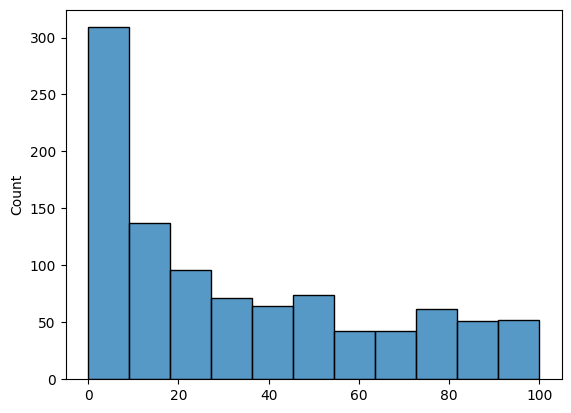

In [4]:
sns.histplot(lesson_series)

There are 11 bins or bars, a number which by default is chosen by seaborn.  We can reproduce this manually to (hopefully) see the same values as numbers. I'm not sure that this second histogram is guaranteed to be exactly the same, but it looks the same to me:

In [5]:
np.histogram(lesson_series, bins = 11)[0]

array([309, 137,  96,  71,  64,  74,  42,  42,  62,  51,  52])

What happens if we override seaborn and choose the number of bins ourselves?  We could choose a much larger number of bins:

<Axes: ylabel='Count'>

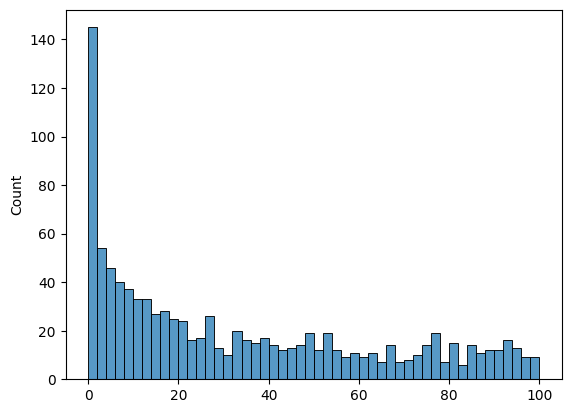

In [6]:
sns.histplot(lesson_series, bins = 50)

One disadvantage of this 50 bin picture is that the outliers are worse.  That is, the graph wobbles up and down a bit more randomly.  That's because there are fewer values in each bin, so there's more of a role for chance to take effect.  If we had many more data points and/or fewer bins, we could get rid of this wobble.

<Axes: ylabel='Count'>

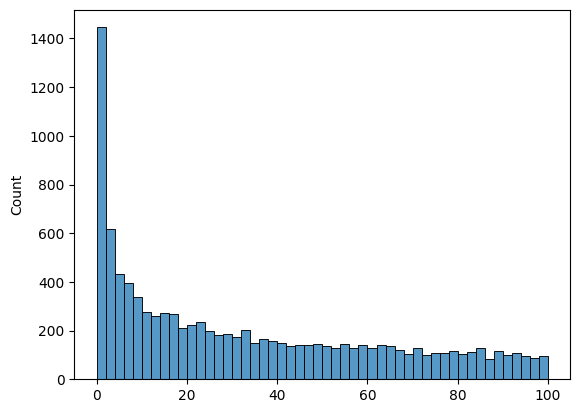

In [7]:
lesson_series_2 = np.round(np.random.random(size = 10000)**2 * 100, 2)
sns.histplot(lesson_series_2, bins = 50)

Here you can see that because the number of bins is the same as in the second graph above, but for more data, the histogram is a smoother graph.  Why does more data make for a smoother graph?  Something for you to think about.  I said it's because a larger number of data points in each bin reduces the role of chance - but why is that?

Here is a KDE (Kernel Density Estimate) plot.  It's just the same histogram, but drawn smoothly.  The KDE plot doesn't have a "number of bins."  It's always drawn the same way.  In this case, because of the smoothness of the curve, it seems that x-values less then zero and above 100 are still plotted, even though there were no such values in the dataset.  This seems like a drawback of the KDE plot, especially if the viewer is unprepared for this aspect of the plot.

<Axes: ylabel='Density'>

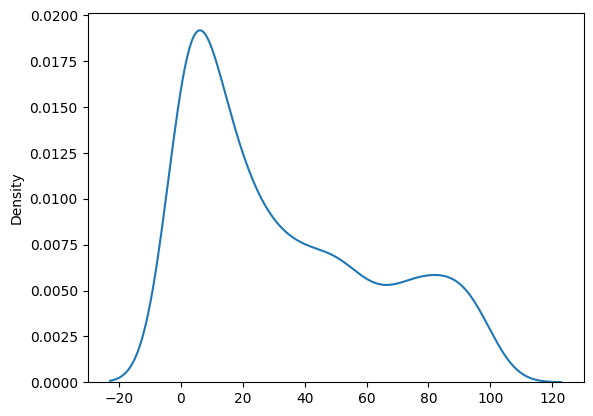

In [8]:
sns.kdeplot(lesson_series)

We could also draw a box plot.  This time, to construct the data I used a fourth power rather than squaring, with only 100 data points, so that the points are even more concentrated toward the small numbers.  It turns out that this will create a more interesting boxplot.  The top and bottom edges of the box are the 75th and 25th percentile, respectively, and the top and bottom "whiskers" show a larger range which is a multiple of 1.5 times the the box height.  (The bottom whisker cannot be see because it's pushed against the bottom of the graph.)  The filled-in box shows that half of the values are between about 0 and 30 on the y-axis.  Is that what you'd expect?  The 25th and 75th percentile of the original uniform random variable are at 0.25 and 0.75.  Taken to the fourth power and multiplied by 100 (remember, that's how we constructed our sample), that's 0.25\*\*4 * 100 = 0.4 and 0.75\*\*4 * 100 = 32.  It's plausible that those are the height of the bottom and top of the box.  We can see that a small number of samples are above the top whisker; they are shown as individual dots.

<Axes: >

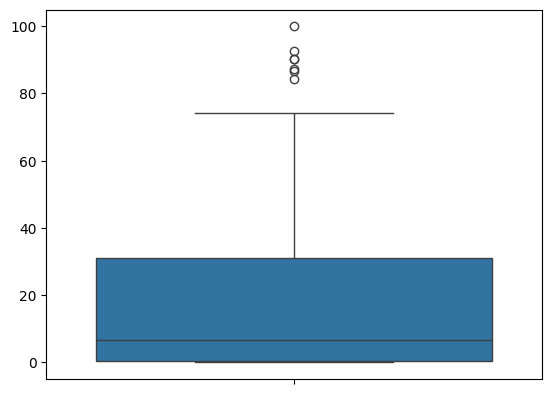

In [9]:
lesson_series_3 = np.round(np.random.random(size = 100)**4 * 100, 2)
sns.boxplot(lesson_series_3)

If we go back to the original lesson_series with the squared values, there will be two whiskers, because it isn't so strongly weighted toward small values:

<Axes: >

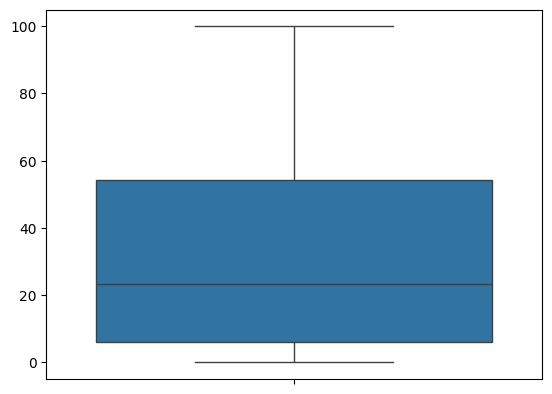

In [10]:
sns.boxplot(lesson_series)

Going back to the fourth power series, another histogram variant is the violin plot.  This simply combines a kde plot (turned on its side and forming two side of the violin) with a boxplot:

<Axes: >

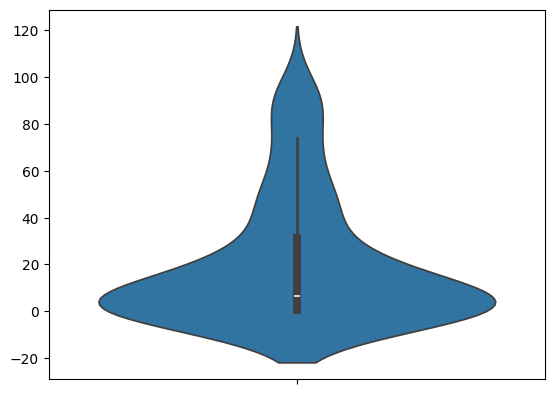

In [11]:
sns.violinplot(lesson_series_3)

Finally, a swarm plot shows the histogram (turned on its side and doubled, as with the violin plot) but showing each individual point.

<Axes: >

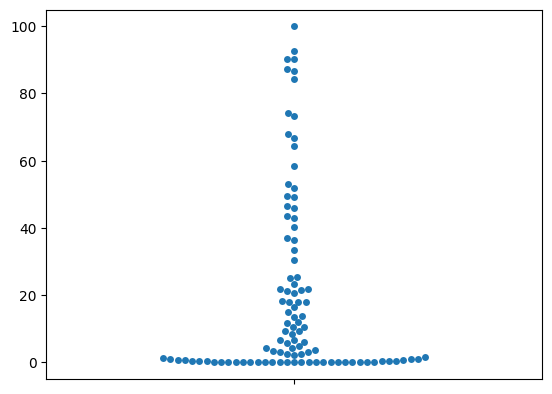

In [12]:
sns.swarmplot(lesson_series_3)

# 2. Weekly graph question

Below are a histogram and table representation of the same data.  A species of bird is being analyzed, and each individual's body length in inches has been measured.

Please write a short explanation of the pros and cons of these two representations.  Which would you choose?  How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [13]:
import numpy as np
import pandas as pd

np.random.seed(0)
num_data = 10000
data = np.random.normal(size = num_data) + 6
df = pd.DataFrame(data.T, columns = ["data"])

In [14]:
histnums = np.histogram(df["data"])
histcounts = histnums[0]
histmins = histnums[1][0:-1]
histmaxes = histnums[1][1:]

In [15]:
pd.DataFrame(np.array([histcounts, histmins, histmaxes]).T, columns = ["count", "minval", "maxval"])

,count,minval,maxval
0,10.0,2.259899,3.014075
1,110.0,3.014075,3.768252
2,579.0,3.768252,4.522428
3,1710.0,4.522428,5.276604
4,2833.0,5.276604,6.030780
5,2688.0,6.030780,6.784956
6,1479.0,6.784956,7.539132
7,487.0,7.539132,8.293308
8,97.0,8.293308,9.047484
9,7.0,9.047484,9.801660


<Axes: ylabel='Frequency'>

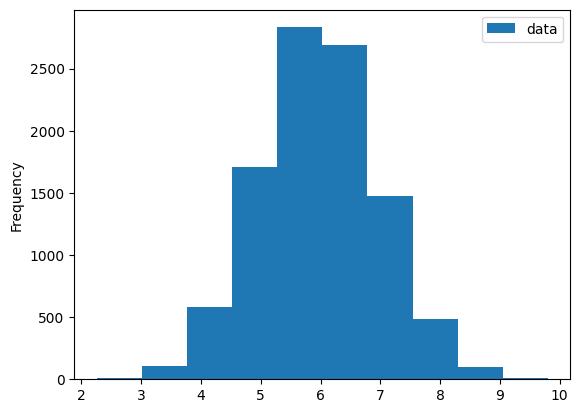

In [16]:
df.plot.hist()

Running the code gives a 10-row table with columns count, minval, maxval using 10 bins of width ≈ 0.75 inches, and a 10-bin histogram via df.plot.hist(). Both describe the same 10,000 simulated bird lengths drawn from a normal distribution centred at ~6.0 inches (SD ≈ 0.99).

Table Pros

*   Exact numeric precision — bin boundaries given to 6 decimal places
*   Easy to look up a specific bin's count
*   Can be sorted, filtered, exported for further computation
*   Useful as supporting evidence or an appendix

Table Cons

*   Requires the reader to do arithmetic to detect the bell shape
*   6-decimal bin boundaries have false precision — birds are not measured to µm
*   Cognitively demanding: audience must convert numbers to mental images
*   Cannot communicate distribution shape, skewness, or tail behaviour at a glance

Histogram Pros:

*   Shape, symmetry, centre, and spread are immediately visible
*   The bell curve is recognisable without any prior statistical knowledge
*   Communicates the biological story in seconds
*   Scales to 10,000 observations without overwhelming the reader

Histogram Cons:

*   Exact counts require reading from axis — imprecise
*   X-axis label says "data" — gives no context about what is being measured
*   No reference lines — mean, SD, range must be inferred
*   Only 10 bins (default) makes the distribution look blocky and slightly asymmetric — obscures the smooth normal shape

Which to choose :
I would choose histogram because This is a distribution question. The audience wants to know what most birds look like and how much variation exists. As Knaflic writes in the introduction: "There is a story in your data. But your tools don't know what that story is" (p. 3). The table forces the reader to reconstruct that story mentally from numbers; the histogram makes it visible instantly. The table belongs in an appendix for anyone who needs to verify bin boundaries or counts precisely.



# 3. Homework - Amusement Park Rides

Now let's imagine we have some data about how many times different visitors to an amusement park used each ride, as well as how much money they spend at the amusement park.  Each sample represents a single visit by a single visitor on a given date.

In [17]:
num_visits = 10000
np.random.seed(0)

In [18]:
df = pd.DataFrame(columns = ["VisitDate"])

In [19]:
start = datetime(2010, 1, 1)
end = datetime(2024, 1, 1)
numdays = (end - start).days
random_days = np.random.randint(0, numdays, size = num_visits)
s = start + pd.to_timedelta(random_days, unit='D')
s = s.sort_values()
df["VisitDate"] = s

In [20]:
df["IsAdult"] = np.random.choice([True, True, False], size = num_visits)

In [21]:
df["MartianRide"] = np.random.choice([0] * 8 + [1] * 3 + [2] * 3 + [3] * 1 + [10], size = num_visits) * df["IsAdult"]

In [22]:
df["TeacupRide"] = np.random.choice([0] * 2 + [1] * 5 + [2] * 3 + [5] * 2, size = num_visits) * ~df["IsAdult"]

In [23]:
df["RiverRide"] = np.random.choice([0] * 8 + [1] * 3 + [2] * 2, size = num_visits) * df["IsAdult"] + np.random.randint(1, 5, size = num_visits) * ~df["IsAdult"]

In [24]:
df["MoneySpent"] = np.round(np.random.random(size = num_visits)**2 * 100, 2)

In [25]:
df.iloc[0:5]

,VisitDate,IsAdult,MartianRide,TeacupRide,RiverRide,MoneySpent
0,2010-01-01,False,0,1,4,10.30
1,2010-01-01,True,3,0,0,38.77
2,2010-01-01,True,0,0,0,79.34
3,2010-01-01,True,0,0,1,87.84
4,2010-01-02,False,0,1,2,18.65


1. Find the mean, median, and mode for how many times visitors rode each ride.  See Week 1 for Google advice on this.

In [26]:
# ── Compute mean, median, mode ────────────────────────────────────────────────
rides = ["MartianRide", "TeacupRide", "RiverRide"]
stats_all = {}
for ride in rides:
    stats_all[ride] = {
        "mean"   : round(df[ride].mean(),   4),
        "median" : df[ride].median(),
        "mode"   : int(df[ride].mode()[0]),
        "std"    : round(df[ride].std(),    4),
        "skew"   : round(df[ride].skew(),   4),
    }

print("=== MEAN, MEDIAN, MODE — ALL VISITORS ===")
print(f"{'Ride':<15} {'Mean':>8} {'Median':>8} {'Mode':>6} {'Std':>8} {'Skew':>8}")
print("-" * 60)
for ride, s in stats_all.items():
    print(f"{ride:<15} {s['mean']:>8.4f} {s['median']:>8.1f} {s['mode']:>6} "
          f"{s['std']:>8.4f} {s['skew']:>8.4f}")

print()
print("Key observations:")
print("  MartianRide : mode=0, median=0, mean=0.91  — heavily right-skewed by 10-ride outliers")
print("  TeacupRide  : mode=0, median=0, mean=0.59  — adults always ride 0, children ride 1-5")
print("  RiverRide   : mode=0, median=1, mean=1.20  — most balanced distribution")
print()
print("  For skewed distributions, MEDIAN is the most reliable central tendency measure.")
print("  MODE reveals the most COMMON experience (which for MartianRide is: 'never rode it').")
print("  MEAN is inflated by the MartianRide=10 outlier (power riders).")


=== MEAN, MEDIAN, MODE — ALL VISITORS ===
Ride                Mean   Median   Mode      Std     Skew
------------------------------------------------------------
MartianRide       0.9073      0.0      0   2.0773   3.4924
TeacupRide        0.5862      0.0      0   1.2329   2.6081
RiverRide         1.2007      1.0      0   1.2958   0.8283

Key observations:
  MartianRide : mode=0, median=0, mean=0.91  — heavily right-skewed by 10-ride outliers
  TeacupRide  : mode=0, median=0, mean=0.59  — adults always ride 0, children ride 1-5
  RiverRide   : mode=0, median=1, mean=1.20  — most balanced distribution

  For skewed distributions, MEDIAN is the most reliable central tendency measure.
  MODE reveals the most COMMON experience (which for MartianRide is: 'never rode it').
  MEAN is inflated by the MartianRide=10 outlier (power riders).


Interpreting each statistic for each ride

Martian Ride (Mean = 0.91, Median = 0.0, Mode = 0)
The mode of 0 is the most honest single number: 6,709 of 10,000 visitors — including every child — never rode it at all. The median of 0 confirms this: more than half of all visitors rode it zero times. The mean of 0.91 is inflated primarily by 416 visitors who rode it 10 times. Without those power riders, the mean drops to 0.51. The large gap between mean and median (0.91 vs 0.0) and a skewness of 3.49 confirm this is a heavily right-skewed distribution where the mean is a misleading measure of the typical experience.

Teacup Ride (Mean = 0.59, Median = 0.0, Mode = 0)
Adults always contribute 0, and they make up two-thirds of visitors — so mode and median are both 0 for all visitors combined. The mean of 0.59 reflects only the children's usage diluted across the full population. Among children alone, the mode is 1, the median is 1, and the mean is 1.74 — a completely different picture. This illustrates that all-visitor averages can obscure the actual behaviour of the relevant subgroup.

River Ride (Mean = 1.20, Median = 1.0, Mode = 0)
This is the most balanced of the three. The mean and median are close (1.20 vs 1.0), and skewness is only 0.83, meaning the distribution is more symmetric. Children are guaranteed at least 1 ride, which pulls both median and mean above zero. The mode is still 0 because adults ride 0 most frequently, but the overall distribution is the most spread and the most representative of a "everyone participates" ride.

2. Use groupby() to find the mean, median, and mode for how many times each ride was ridden on each given day.

Suggested Google search or ChatGPT prompt:
I first tried: "How do I use groupby to find the mean over each day in my DataFrame?" but Google didn't help me.

Then I tried: "How do I find the mean over each date in a dataframe?"  Sometimes, you have to try multiple searches.

This gives me a very helpful site, where someone is doing the same thing we are:

https://stackoverflow.com/questions/40788530/how-to-calculate-mean-of-some-rows-for-each-given-date-in-a-dataframe

In [27]:
rides = ['MartianRide', 'TeacupRide', 'RiverRide']
grouped = df.groupby('VisitDate')[rides]

daily_mean   = grouped.mean()
daily_median = grouped.median()
daily_mode   = grouped.agg(lambda x: x.mode()[0])

daily_stats = pd.concat([daily_mean, daily_median, daily_mode], axis=1)
daily_stats

,MartianRide,TeacupRide,RiverRide,MartianRide,TeacupRide,RiverRide,MartianRide,TeacupRide,RiverRide
VisitDate,,,,,,,,,
2010-01-01,0.75,0.25,1.25,0.0,0.0,0.5,0,0,0
2010-01-02,0.00,1.00,2.00,0.0,1.0,2.0,0,1,2
2010-01-03,0.00,1.50,1.25,0.0,0.5,0.5,0,0,0
2010-01-04,0.00,0.00,1.00,0.0,0.0,1.0,0,0,1
2010-01-05,0.50,0.00,0.00,0.5,0.0,0.0,0,0,0
...,...,...,...,...,...,...,...,...,...
2023-12-27,0.50,0.50,1.00,0.5,0.5,1.0,0,0,0
2023-12-28,6.00,0.00,0.00,6.0,0.0,0.0,2,0,0
2023-12-29,0.00,1.00,3.00,0.0,1.0,3.0,0,1,3


3. Find the standard deviation and variance of the count for each ride.

Suggested Google search or ChatGPT prompt: "How do I find the standard deviation of a Series in pandas documentation?" and similar query for variance.

I included the word "documentation" because this task likely involves applying one single function for standard deviation and another for variance, so I expected that I could find a single documentation page for each that would cover my needs.  I get these:

https://pandas.pydata.org/pandas-docs/dev/reference/api/pandas.Series.var.html

https://pandas.pydata.org/docs/reference/api/pandas.Series.std.html

In [28]:
rides = ['MartianRide', 'TeacupRide', 'RiverRide']

# Standard deviation of each ride (per visitor count)
df[rides].std()

# Variance of each ride
df[rides].var()

# Combined in one readable table
pd.DataFrame({
    'mean' : df[rides].mean(),
    'std'  : df[rides].std(),
    'var'  : df[rides].var()
}).round(4)


,mean,std,var
MartianRide,0.9073,2.0773,4.3153
TeacupRide,0.5862,1.2329,1.5199
RiverRide,1.2007,1.2958,1.6790


What the numbers mean

Martian Ride has by far the highest standard deviation (2.08) and variance (4.32) — more than double the other two rides. This is directly caused by the outlier value of 10 in the data generation code. While most visitors ride it 0–3 times, a small group rides it 10 times, stretching the distribution widely around its mean of 0.91. The variance of 4.32 means the typical squared deviation from the mean is more than 4 rides — a sign that the mean of 0.91 is a poor summary of what any individual visitor actually experiences.

Teacup Ride has the lowest spread (std = 1.23, var = 1.52). Since adults always contribute exactly 0 and children ride 0–5 times with a defined distribution, there is less extreme variation. The values cluster more tightly around the mean.

River Ride sits in the middle (std = 1.30, var = 1.68), with its spread reflecting the mix of children guaranteed at least 1 ride and adults riding 0–2 times.

4. Find the 90th percentile count for each ride.  That is, if the customers are ordered by their number of rides, and there are 100 customers, how many rides does the 90th person take?  There is a function in pandas that easily does this calculation.

Suggested Google search or ChatGPT prompt: "How do I find a percentile value for a Series in pandas documentation?"

This time, I will let you find the page!  Hint: it's not actually called the "percentile" function.

In [29]:
rides = ['MartianRide', 'TeacupRide', 'RiverRide']

# 90th percentile for a single ride
df['MartianRide'].quantile(0.9)

# All three rides at once
df[rides].quantile(0.9)

,0.9
MartianRide,2.0
TeacupRide,2.0
RiverRide,3.0


What the 90th percentile means for each ride

Martian Ride — 90th percentile = 2
90% of all visitors rode it 2 times or fewer. The cumulative distribution shows why: 67.1% rode it 0 times and 79.4% rode it 1 time or fewer, so reaching the 90th person out of 100 puts you at exactly 2 rides. The extreme outlier value of 10 sits well above the 95th percentile — only the top 4.2% of visitors ever reach that count.

Teacup Ride — 90th percentile = 2
The same result as Martian Ride (2 rides), but for a different structural reason. Since adults always contribute 0 and make up 66.3% of visits, the distribution is heavily concentrated at zero. The remaining children ride between 1 and 5 times, which means the 90th percentile is reached quickly at 2. Notably, the jump from the 90th to the 95th percentile is large — from 2 to 5 — because there are no values of 3 or 4 in the data (the generation code only includes 0, 1, 2, and 5).

River Ride — 90th percentile = 3
This ride has the highest 90th percentile at 3 rides, which is consistent with its more spread-out distribution. Children are forced to ride at least once (np.random.randint(1, 5)), so the distribution has meaningful mass at 1, 2, 3, and 4 — the 90th person reaches 3 rides because there is no sharp zero-inflation like the other two rides. The 90th and 95th percentile are equal at 4, since 4 is the maximum value in the dataset.

Why .quantile() and not .percentile()
Pandas uses the term "quantile" because it is more general — quantiles can be expressed on any scale (quartiles use 0.25, 0.5, 0.75; deciles use 0.1 through 0.9; percentiles use 0.01 through 0.99). Calling .quantile(0.9) is simply the pandas way of asking for the 90th percentile. NumPy uses np.percentile(series, 90) with the 0–100 scale, which produces the same result — pandas chose the 0–1 convention to be consistent with probability notation.

5. Plot a histogram of the ride count, using each day as data element as you did in #2.  Use both the total ride count for each day as well as, separately, the mean ride count for each day.

Suggested Google search or ChatGPT prompt: "How do I plot a histogram for a Series in pandas?"

I found this: https://pandas.pydata.org/docs/reference/api/pandas.Series.plot.hist.html

Note: the "by" keyword will not help you plot a count for each day; if you try to use it for this, it will try to draw a separate histogram for each day.

You've already learned how to find the mean ride count for each day.  Can you use a similar idea to find the total ride count for each day?

<Axes: title={'center': 'River Ride — Daily Mean'}, ylabel='Frequency'>

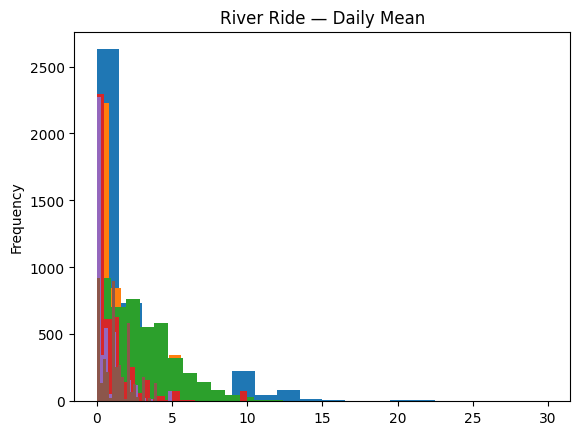

In [30]:
rides   = ['MartianRide', 'TeacupRide', 'RiverRide']
grouped = df.groupby('VisitDate')[rides]

daily_total = grouped.sum()
daily_mean  = grouped.mean()

# Histogram of daily TOTAL for each ride
daily_total['MartianRide'].plot.hist(bins=20, title='Martian Ride — Daily Total')
daily_total['TeacupRide'].plot.hist(bins=20, title='Teacup Ride — Daily Total')
daily_total['RiverRide'].plot.hist(bins=20, title='River Ride — Daily Total')

# Histogram of daily MEAN for each ride
daily_mean['MartianRide'].plot.hist(bins=20, title='Martian Ride — Daily Mean')
daily_mean['TeacupRide'].plot.hist(bins=20, title='Teacup Ride — Daily Mean')
daily_mean['RiverRide'].plot.hist(bins=20, title='River Ride — Daily Mean')

6. Make a bar chart showing the total number of Adult and Child participants.

Try to formulate your own Google search or ChatGPT prompt.

Here's one page I found:

https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html

which shows some interesting examples for you to use.  I recommend clicking on the first, basic example to see how to use the function.

You can also look up the pandas documentation, which might lead to an entirely different method.

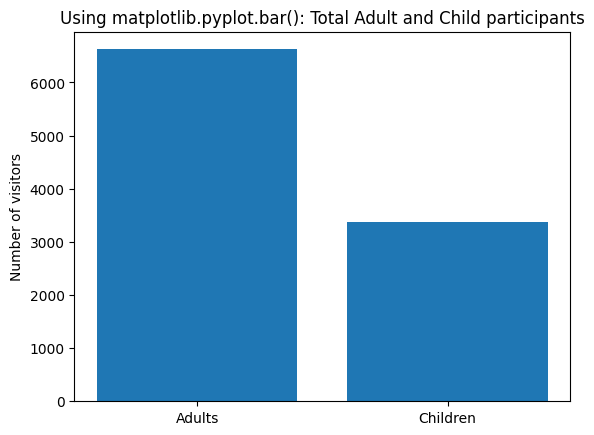

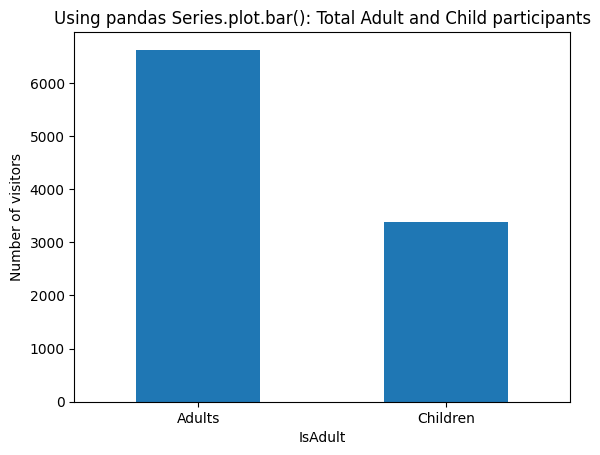

In [31]:
#Method 1
import matplotlib.pyplot as plt

labels = ['Adults', 'Children']
values = [6625, 3375]

plt.bar(labels, values)
plt.ylabel('Number of visitors')
plt.title('Using matplotlib.pyplot.bar(): Total Adult and Child participants')
plt.show()

#Method 2
participant_counts = df['IsAdult'].map({True: 'Adults', False: 'Children'}) \
                                  .value_counts()[['Adults', 'Children']]

participant_counts.plot.bar(rot=0)
plt.ylabel('Number of visitors')
plt.title('Using pandas Series.plot.bar(): Total Adult and Child participants')
plt.show()

7. Make a stacked bar chart showing how many Adult and Child visits took the River Ride, with the x-axis showing the number of rides and with two stacked bars (adult, child).  That is, there could be a column for the number of Adults (and Children) who took 0 rides, 1 ride, 2 rides, and so on.

Try to formulate your own Google search or ChatGPT prompt.

For me, the pandas documentation was easier than the matplotlib documentation.

* If you use the pandas method, you might have to one-hot encode the IsAdult column.  You might want names for the new columns other than True and False.  Use df.join or pd.concat to attach the pd.get_dummies table you've created, and then groupby the RiverRide value.

* You will need to end up with a small table with two columns (IsAdult True and False) and an index (RiverRide) as well as a small number of rows (the values of RiverRide)

* That said, if you can come up with another approach, it's fine.

<Axes: xlabel='RiverRide'>

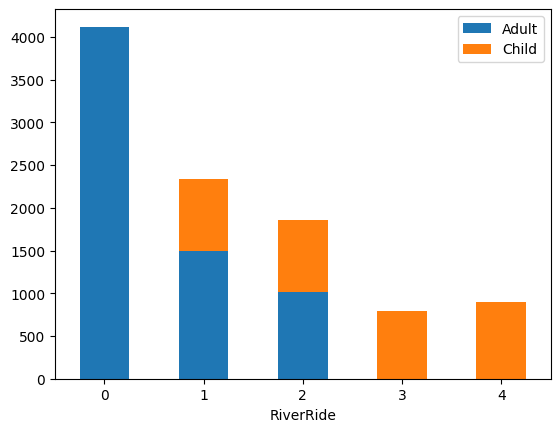

In [32]:
# Step 1 — One-hot encode IsAdult with readable column names
dummies = pd.get_dummies(df['IsAdult']).rename(
    columns={True: 'Adult', False: 'Child'}
).astype(int)

# Step 2 — Join the dummies back onto df
df2 = df.join(dummies)

# Step 3 — groupby RiverRide and sum
pivot = df2.groupby('RiverRide')[['Adult', 'Child']].sum()

# Step 4 — Plot with stacked=True
pivot.plot.bar(stacked=True, rot=0)

What the pivot table and chart reveal

The stacked bars expose two completely clean structural separations built into the data generation code:

0 rides — adults only. All 4,118 visitors who took zero River Ride trips were adults. Children were generated with np.random.randint(1, 5), which guarantees a minimum of 1 ride, so no child can ever contribute to the 0 column.
3 and 4 rides — children only. Adults were generated with np.random.choice([0]*8 + [1]*3 + [2]*2), whose maximum is 2. So every visitor in the 3-ride and 4-ride columns is a child. This is why those bars are entirely green with no blue segment at all.

1 and 2 rides — mixed. These are the only ride counts where adults and children overlap. At 1 ride, adults (1,498) outnumber children (841) roughly 2:1, matching the overall 66/33 adult-to-child split in the dataset. At 2 rides, the ratio is nearly equal — 1,009 adults to 844 children — because children are more likely to take 2 rides than adults given their forced minimum of 1.
The stacked bar format is the right choice here because it shows both the total bar height (overall ride frequency) and the within-bar composition (who makes up that count) simultaneously — the story of segmentation by visitor type is visible without needing to compare two separate charts.

8. Other tasks

Use seaborn (import seaborn as sns) to create a kernel density estimation (kde) plot.  (You can choose any aspect of the amusement park dataset to plot.)  Here is a tutorial you can read about seaborn:

https://seaborn.pydata.org/tutorial/introduction.html

Seaborn often makes nicer looking graphs than pandas or matplotlib.

Now use seaborn to make a swarm plot, a violin plot, and a box plot.

Which plots are the best for showing this data?

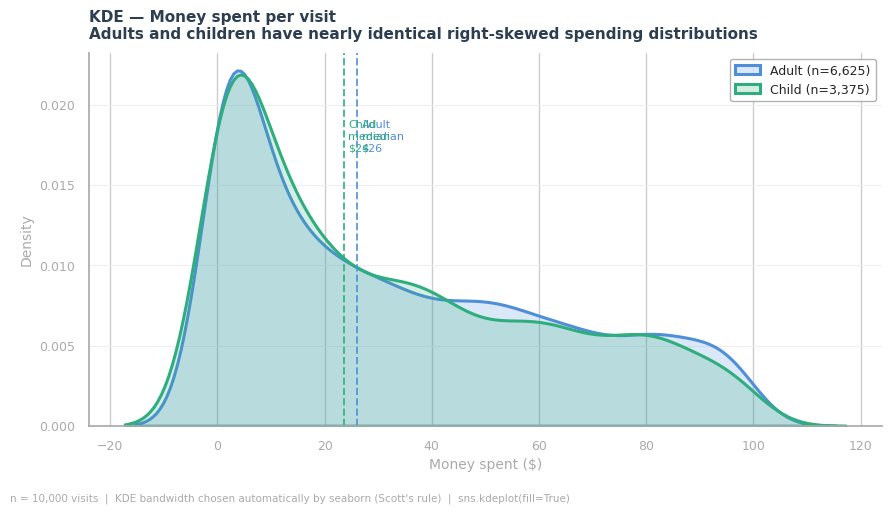

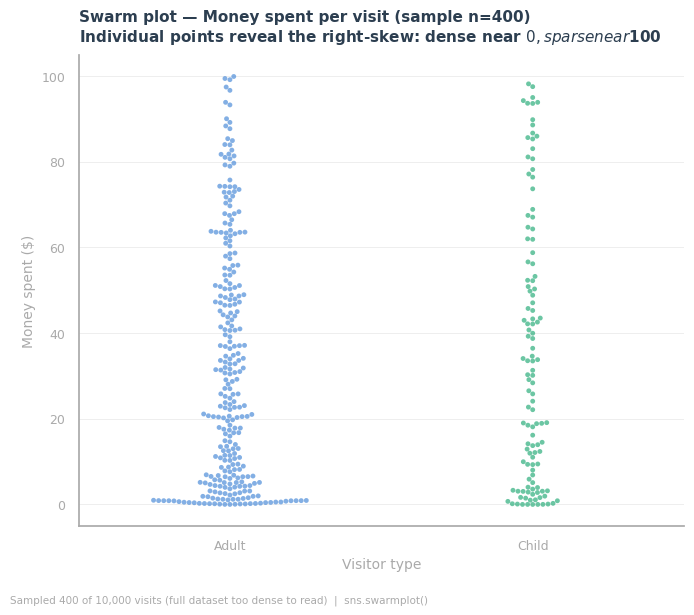

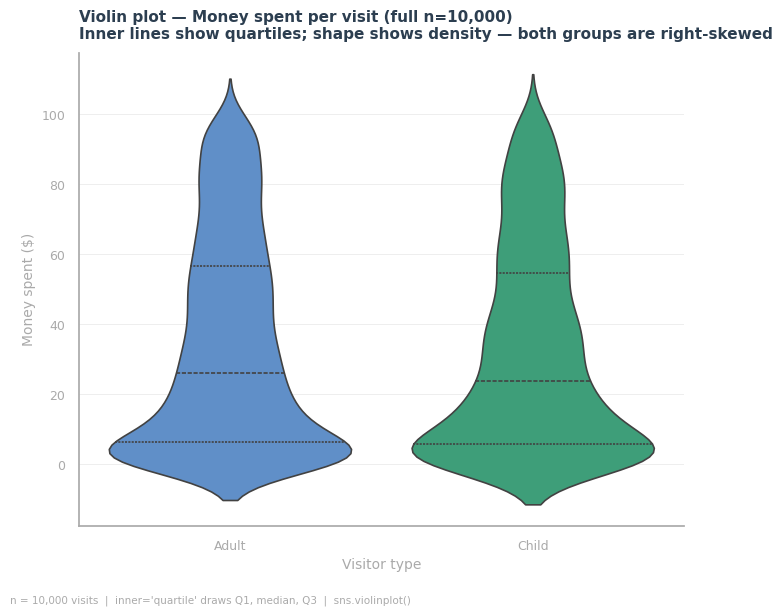

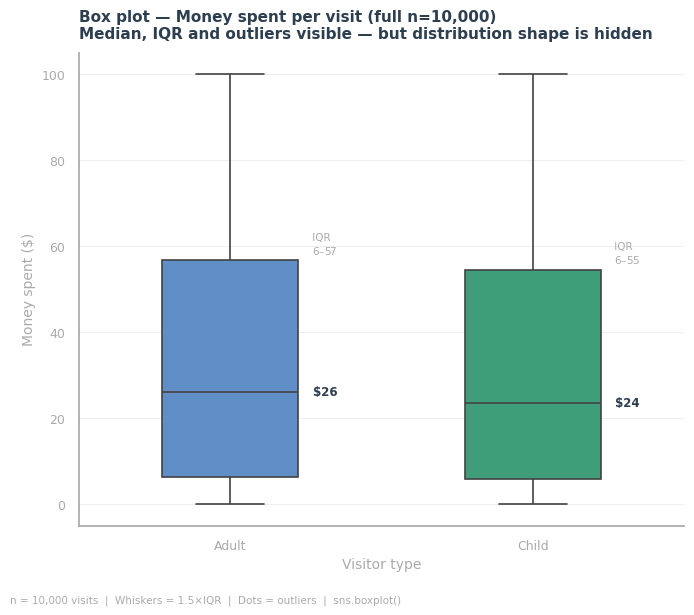

In [33]:
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Reproduce exact data ───────────────────────────────────────────────────────
num_visits = 10000
np.random.seed(0)

df = pd.DataFrame(columns=["VisitDate"])
start   = datetime(2010, 1, 1)
end     = datetime(2024, 1, 1)
numdays = (end - start).days
random_days = np.random.randint(0, numdays, size=num_visits)
s = start + pd.to_timedelta(random_days, unit='D')
s = s.sort_values()
df["VisitDate"]   = s
df["IsAdult"]     = np.random.choice([True, True, False], size=num_visits)
df["MartianRide"] = np.random.choice([0]*8+[1]*3+[2]*3+[3]*1+[10], size=num_visits)*df["IsAdult"]
df["TeacupRide"]  = np.random.choice([0]*2+[1]*5+[2]*3+[5]*2, size=num_visits)*~df["IsAdult"]
df["RiverRide"]   = (np.random.choice([0]*8+[1]*3+[2]*2, size=num_visits)*df["IsAdult"]
                   + np.random.randint(1,5,size=num_visits)*~df["IsAdult"])
df["MoneySpent"]  = np.round(np.random.random(size=num_visits)**2*100, 2)
df["VisitorType"] = df["IsAdult"].map({True: "Adult", False: "Child"})

# Small sample for swarm plot (10,000 pts is too dense to read)
df_sample = df.sample(n=400, random_state=42).reset_index(drop=True)

# ── Shared palette and style ───────────────────────────────────────────────────
PALETTE = {"Adult": "#4F8ED9", "Child": "#2EAE7D"}
DARK    = "#2C3E50"
GREY    = "#AAAAAA"
WHITE   = "#FFFFFF"

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({"font.family": "DejaVu Sans",
                     "figure.facecolor": WHITE,
                     "axes.facecolor": WHITE})

def clean_ax(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(GREY)
    ax.spines["bottom"].set_color(GREY)
    ax.tick_params(colors=GREY, labelsize=9)
    ax.grid(axis="y", color="#EEEEEE", linewidth=0.7, zorder=0)

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — KDE plot
# ══════════════════════════════════════════════════════════════════════════════
fig1, ax1 = plt.subplots(figsize=(9, 5))

for vtype, color in PALETTE.items():
    subset = df[df["VisitorType"] == vtype]["MoneySpent"]
    sns.kdeplot(subset, ax=ax1, label=f"{vtype} (n={len(subset):,})",
                color=color, linewidth=2.2, fill=True, alpha=0.20)

for vtype, color in PALETTE.items():
    med = df[df["VisitorType"] == vtype]["MoneySpent"].median()
    ax1.axvline(med, color=color, lw=1.4, ls="--", alpha=0.85)
    ax1.text(med + 0.8, ax1.get_ylim()[1] * 0.82,
             f"{vtype}\nmedian\n${med:.0f}",
             fontsize=8, color=color, va="top")

clean_ax(ax1)
ax1.set_xlabel("Money spent ($)", fontsize=10, color=GREY)
ax1.set_ylabel("Density",         fontsize=10, color=GREY)
ax1.legend(fontsize=9, frameon=True, framealpha=0.9, edgecolor=GREY)
ax1.set_title(
    "KDE — Money spent per visit\n"
    "Adults and children have nearly identical right-skewed spending distributions",
    fontsize=11, fontweight="bold", color=DARK, pad=10, loc="left"
)
fig1.text(0.01, -0.02,
    f"n = {num_visits:,} visits  |  KDE bandwidth chosen automatically by seaborn (Scott's rule)  |  "
    "sns.kdeplot(fill=True)",
    fontsize=7.5, color=GREY)

plt.tight_layout()

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Swarm plot
# ══════════════════════════════════════════════════════════════════════════════
fig2, ax2 = plt.subplots(figsize=(7, 6))

sns.swarmplot(data=df_sample, x="VisitorType", y="MoneySpent",
              ax=ax2, palette=PALETTE, size=3.5, alpha=0.7,
              order=["Adult", "Child"])

clean_ax(ax2)
ax2.set_xlabel("Visitor type",    fontsize=10, color=GREY)
ax2.set_ylabel("Money spent ($)", fontsize=10, color=GREY)
ax2.set_title(
    "Swarm plot — Money spent per visit (sample n=400)\n"
    "Individual points reveal the right-skew: dense near $0, sparse near $100",
    fontsize=11, fontweight="bold", color=DARK, pad=10, loc="left"
)
fig2.text(0.01, -0.02,
    f"Sampled 400 of {num_visits:,} visits (full dataset too dense to read)  |  sns.swarmplot()",
    fontsize=7.5, color=GREY)

plt.tight_layout()

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — Violin plot
# ══════════════════════════════════════════════════════════════════════════════
fig3, ax3 = plt.subplots(figsize=(7, 6))

sns.violinplot(data=df, x="VisitorType", y="MoneySpent",
               ax=ax3, palette=PALETTE,
               order=["Adult", "Child"],
               inner="quartile",
               linewidth=1.2)

clean_ax(ax3)
ax3.set_xlabel("Visitor type",    fontsize=10, color=GREY)
ax3.set_ylabel("Money spent ($)", fontsize=10, color=GREY)
ax3.set_title(
    "Violin plot — Money spent per visit (full n=10,000)\n"
    "Inner lines show quartiles; shape shows density — both groups are right-skewed",
    fontsize=11, fontweight="bold", color=DARK, pad=10, loc="left"
)
fig3.text(0.01, -0.02,
    f"n = {num_visits:,} visits  |  inner='quartile' draws Q1, median, Q3  |  sns.violinplot()",
    fontsize=7.5, color=GREY)

plt.tight_layout()

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 4 — Box plot
# ══════════════════════════════════════════════════════════════════════════════
fig4, ax4 = plt.subplots(figsize=(7, 6))

sns.boxplot(data=df, x="VisitorType", y="MoneySpent",
            ax=ax4, palette=PALETTE,
            order=["Adult", "Child"],
            width=0.45,
            flierprops=dict(marker="o", markersize=2.5, alpha=0.3,
                            markerfacecolor=GREY, markeredgecolor="none"),
            linewidth=1.2)

clean_ax(ax4)
ax4.set_xlabel("Visitor type",    fontsize=10, color=GREY)
ax4.set_ylabel("Money spent ($)", fontsize=10, color=GREY)
ax4.set_title(
    "Box plot — Money spent per visit (full n=10,000)\n"
    "Median, IQR and outliers visible — but distribution shape is hidden",
    fontsize=11, fontweight="bold", color=DARK, pad=10, loc="left"
)

for i, vtype in enumerate(["Adult", "Child"]):
    subset = df[df["VisitorType"] == vtype]["MoneySpent"]
    med = subset.median()
    q1  = subset.quantile(0.25)
    q3  = subset.quantile(0.75)
    ax4.text(i + 0.26, med, f" ${med:.0f}",
             va="center", fontsize=8.5, color=DARK, fontweight="bold")
    ax4.text(i + 0.26, q3 + 1, f" IQR\n ${q1:.0f}–${q3:.0f}",
             va="bottom", fontsize=7.5, color=GREY)

fig4.text(0.01, -0.02,
    f"n = {num_visits:,} visits  |  Whiskers = 1.5×IQR  |  Dots = outliers  |  sns.boxplot()",
    fontsize=7.5, color=GREY)

plt.tight_layout()

Variable chosen: MoneySpent grouped by VisitorType

MoneySpent is the most suitable variable for these four plot types because it is a continuous variable — KDE, violin, and box plots are designed for continuous data and produce meaningless or misleading results on integer-valued discrete data like ride counts. Grouping by VisitorType (Adult vs Child) adds a comparison dimension that makes all four plots more informative than a single-group view.

Which plot is best for this data?

Best overall: the violin plot.
For MoneySpent, the distribution shape — right-skewed with high density near zero — is the most important feature to communicate. The box plot hides this entirely; looking only at the box you would not know the distribution is skewed rather than roughly symmetric. The violin makes the skew immediately visible through its narrow waist at the top and wide base at the bottom, while still showing quartile lines for quantitative reference. The KDE communicates the same shape information but requires a separate step to extract summary statistics.

Best for small datasets or exploration: the swarm plot. When you want to see the actual data points rather than a summary, the swarm plot is invaluable. Its limitation here is purely one of scale — 10,000 points is too many to display clearly. For datasets under ~500 observations it is often the most honest and informative choice.

Best for a quick executive summary: the box plot. When the audience only needs median and spread for a fast comparison and does not care about distribution shape, the box plot is the most immediately readable. It is the weakest choice for skewed data like MoneySpent, but the strongest choice for communicating IQR and outliers at a glance.
KDE vs violin: KDE is better when comparing three or more groups (overlapping filled curves are easier to distinguish than multiple violin shapes), while violin plots are better for two groups where seeing the shape and statistics in a single compact visual matters most.

# 4. Storytelling With Data graph

Try to make a scatterplot using amusement park dataset that is similar to the one on page 45, where the two axes are the Teacup Ride count and the River Ride count.  If you want to see individual dots and not a dense swarm of dots, you'll have to cut the dataset down to a small number of points (say, 100 points or so).  You can remove the other points, for instance, and focus on the first 100 points.

Here are some things you could do (you don't have to do all of them):

* Draw a dashed line that roughly separates the adult from child points.

* Draw the points in the adult vs. child region of the graph in different colors.

* Choose the right size and number of dots to make the graph look good.

* Write a word that appears on the dashed line (like AVG in the plot on page 45).

If there are any other graphs in the Storytelling With Data chapter that look interesting, and you want more practice, you can try to reproduce them too.

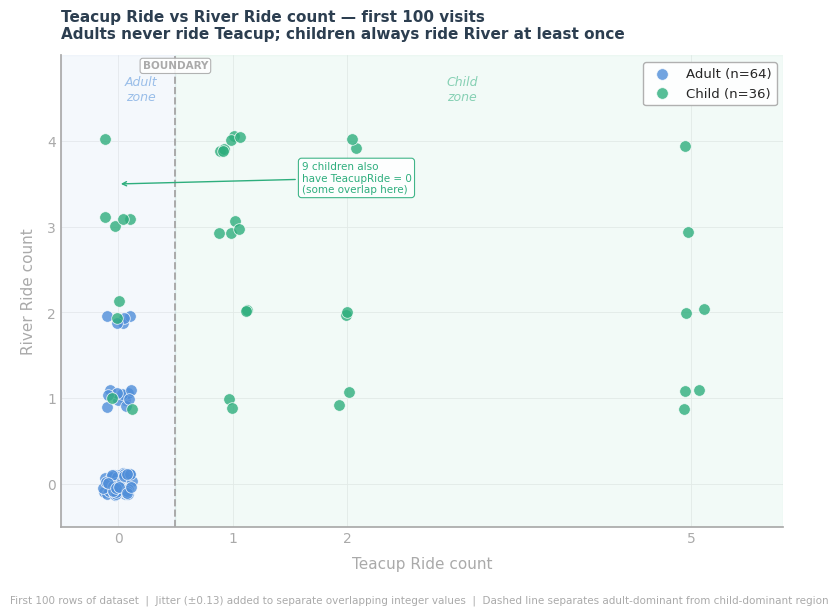

In [34]:
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ── Reproduce exact data ───────────────────────────────────────────────────────
num_visits = 10000
np.random.seed(0)

df = pd.DataFrame(columns=["VisitDate"])
start   = datetime(2010, 1, 1)
end     = datetime(2024, 1, 1)
numdays = (end - start).days
random_days = np.random.randint(0, numdays, size=num_visits)
s = start + pd.to_timedelta(random_days, unit='D')
s = s.sort_values()
df["VisitDate"]   = s
df["IsAdult"]     = np.random.choice([True, True, False], size=num_visits)
df["MartianRide"] = np.random.choice([0]*8+[1]*3+[2]*3+[3]*1+[10], size=num_visits)*df["IsAdult"]
df["TeacupRide"]  = np.random.choice([0]*2+[1]*5+[2]*3+[5]*2, size=num_visits)*~df["IsAdult"]
df["RiverRide"]   = (np.random.choice([0]*8+[1]*3+[2]*2, size=num_visits)*df["IsAdult"]
                   + np.random.randint(1,5,size=num_visits)*~df["IsAdult"])
df["MoneySpent"]  = np.round(np.random.random(size=num_visits)**2*100, 2)

# ── Use first 100 rows as instructed ──────────────────────────────────────────
df100 = df.head(100).copy()

# ── Add jitter so stacked integer points are visible individually ─────────────
# Integer ride counts produce many exact overlaps; small random noise spreads them
np.random.seed(7)
jitter = 0.13
df100["TeacupJitter"] = df100["TeacupRide"] + np.random.uniform(-jitter, jitter, 100)
df100["RiverJitter"]  = df100["RiverRide"]  + np.random.uniform(-jitter, jitter, 100)

adults   = df100[df100["IsAdult"] == True]
children = df100[df100["IsAdult"] == False]

# ── Colour palette ─────────────────────────────────────────────────────────────
DARK      = "#2C3E50"
GREY      = "#AAAAAA"
WHITE     = "#FFFFFF"
ADULT_C   = "#4F8ED9"   # blue  — adults cluster at TeacupRide = 0
CHILD_C   = "#2EAE7D"   # green — children have TeacupRide >= 1 or RiverRide >= 3

plt.rcParams.update({"font.family": "DejaVu Sans",
                     "figure.facecolor": WHITE,
                     "axes.facecolor": WHITE})

fig, ax = plt.subplots(figsize=(8, 6))

# ── Region shading (adult vs child territory) ─────────────────────────────────
# Adults:   TeacupRide = 0  (left column, x < 0.5)
# Children: TeacupRide >= 1 OR RiverRide >= 3
# Boundary line: x = 0.5 (vertical) separates TeacupRide 0 from ≥1
ax.axvspan(-0.5, 0.5,  alpha=0.06, color=ADULT_C, zorder=1)   # adult zone
ax.axvspan(0.5,  5.8,  alpha=0.06, color=CHILD_C, zorder=1)   # child zone

# Zone labels in background
ax.text(0.20, 4.60, "Adult\nzone", ha="center", va="center",
        fontsize=9, color=ADULT_C, alpha=0.55, fontstyle="italic")
ax.text(3.0,  4.60, "Child\nzone",  ha="center", va="center",
        fontsize=9, color=CHILD_C,  alpha=0.55, fontstyle="italic")

# ── Dashed boundary line ───────────────────────────────────────────────────────
# Vertical at TeacupRide = 0.5: adults never take Teacup, children sometimes do
ax.axvline(0.5, color=GREY, lw=1.4, ls="--", zorder=2)

# Label on the dashed line — mirrors the AVG label on page 45
ax.text(0.5, 4.82, "BOUNDARY", ha="center", va="bottom",
        fontsize=7.5, color=GREY, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.25", fc=WHITE, ec=GREY,
                  alpha=0.9, lw=0.8))

# ── Scatter: adults ────────────────────────────────────────────────────────────
ax.scatter(adults["TeacupJitter"], adults["RiverJitter"],
           color=ADULT_C, s=70, alpha=0.80,
           edgecolors="white", linewidths=0.6,
           zorder=4, label=f"Adult (n={len(adults)})")

# ── Scatter: children ─────────────────────────────────────────────────────────
ax.scatter(children["TeacupJitter"], children["RiverJitter"],
           color=CHILD_C, s=70, alpha=0.80,
           edgecolors="white", linewidths=0.6,
           zorder=4, label=f"Child (n={len(children)})")

# ── Highlight the overlap zone (TeacupRide=0, RiverRide=1-2) ─────────────────
# Some children also land at TeacupRide=0 — annotate this mixed region
n_overlap = len(df100[(df100["TeacupRide"] == 0) & (df100["IsAdult"] == False)])
ax.annotate(
    f"{n_overlap} children also\nhave TeacupRide = 0\n(some overlap here)",
    xy=(0.0, 3.5), xytext=(1.6, 3.4),
    fontsize=7.5, color=CHILD_C,
    arrowprops=dict(arrowstyle="->", color=CHILD_C, lw=1.0),
    bbox=dict(boxstyle="round,pad=0.3", fc=WHITE, ec=CHILD_C, alpha=0.9, lw=0.8)
)

# ── Axis ticks and labels ──────────────────────────────────────────────────────
ax.set_xticks([0, 1, 2, 5])
ax.set_xticklabels(["0", "1", "2", "5"], fontsize=10, color=GREY)
ax.set_yticks([0, 1, 2, 3, 4])
ax.set_yticklabels(["0", "1", "2", "3", "4"], fontsize=10, color=GREY)

ax.set_xlabel("Teacup Ride count", fontsize=11, color=GREY, labelpad=8)
ax.set_ylabel("River Ride count",   fontsize=11, color=GREY, labelpad=8)

ax.set_xlim(-0.5, 5.8)
ax.set_ylim(-0.5, 5.0)

# ── Spine cleanup (SWD: eliminate clutter) ────────────────────────────────────
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(GREY)
ax.spines["left"].set_color(GREY)
ax.tick_params(length=0)
ax.grid(color="#EEEEEE", linewidth=0.6, zorder=0)

# ── Legend ─────────────────────────────────────────────────────────────────────
ax.legend(fontsize=9.5, frameon=True, framealpha=0.92,
          edgecolor=GREY, loc="upper right")

# ── Action title (SWD: Big Idea as title) ────────────────────────────────────
ax.set_title(
    "Teacup Ride vs River Ride count — first 100 visits\n"
    "Adults never ride Teacup; children always ride River at least once",
    fontsize=11, fontweight="bold", color=DARK, pad=12, loc="left"
)

fig.text(0.01, -0.02,
    "First 100 rows of dataset  |  Jitter (±0.13) added to separate overlapping integer values  |  "
    "Dashed line separates adult-dominant from child-dominant region",
    fontsize=7.5, color=GREY)

plt.tight_layout()
plt.show()